# Первичный анализ датасета Tips (чаевые)
Цель: загрузить данные, изучить их структуру, наличие пропусков и построить базовые визуализации.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуального стиля графиков
sns.set_theme(style="whitegrid")

In [8]:
# Используем относительный путь: поднимаемся на уровень выше из notebooks/ и заходим в data/
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [9]:
print(f"Размер таблицы (строки, столбцы): {df.shape}\n")

print("Типы столбцов:")
print(df.dtypes)
print("\nЧисло пропусков по столбцам:")
print(df.isnull().sum())

Размер таблицы (строки, столбцы): (244, 7)

Типы столбцов:
total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

Число пропусков по столбцам:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [10]:
# include='all' позволяет увидеть статистики и для категориальных признаков
df.describe(include='all')

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


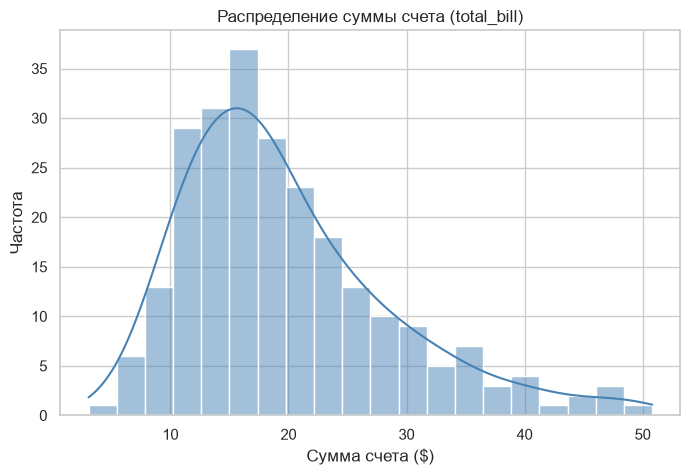

In [11]:
plt.figure(figsize=(8, 5))
# Строим гистограмму распределения суммы счета
sns.histplot(data=df, x='total_bill', kde=True, bins=20, color='steelblue')
plt.title('Распределение суммы счета (total_bill)')
plt.xlabel('Сумма счета ($)')
plt.ylabel('Частота')
plt.show()

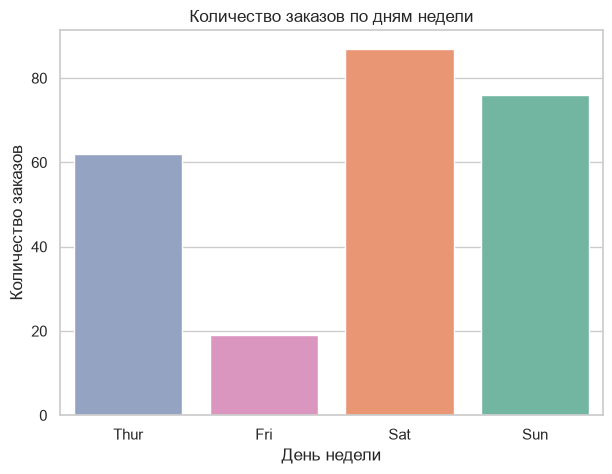

In [15]:
plt.figure(figsize=(7, 5))
# Строим столбчатую диаграмму количества заказов по дням недели
sns.countplot(data=df, x='day', hue='day', palette='Set2', legend=False, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.show()

### Содержательные наблюдения о данных:
1. **Распределение чеков скошено вправо:** Основная масса счетов находится в диапазоне от 10 до 25 долларов. Существуют редкие, но крупные счета (свыше 40 долларов), которые создают длинный «хвост» распределения.
2. **Пиковые дни:** Наибольшая загруженность ресторана (по количеству транзакций) приходится на выходные дни — субботу и воскресенье. Пятница является самым непопулярным днем среди представленных.
3. **Чистота данных:** Датасет является идеально полным. Пропуски отсутствуют во всех столбцах, что позволяет переходить к этапу машинного обучения без дополнительной импутации (заполнения пропусков) данных.